In [217]:

# visualisation
# Import the necessary library
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import cm
# import seaborn library
import seaborn as sns

import pandas as pd
import numpy as np
import sys
import numbers

# pathlib
from pathlib import Path
# 
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram

In [142]:

LCL_PATH   = str(Path().cwd())
ROOT_PATH  = str(Path(LCL_PATH).parent)
DEEPL_PATH = "/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning"
DS_PATH  = str(Path(ROOT_PATH)/"data")
info_msg = """
root path:\t{}
local path:\t{}
dataset path:\t{}
deep learning path:\t{}""".format(ROOT_PATH, LCL_PATH, DS_PATH, DEEPL_PATH)
print(info_msg)


root path:	/home/gheorghe/Desktop/Proiecte/master/DM
local path:	/home/gheorghe/Desktop/Proiecte/master/DM/task03
dataset path:	/home/gheorghe/Desktop/Proiecte/master/DM/data
deep learning path:	/home/gheorghe/Desktop/Proiecte/master/CARN/deep_learning


In [3]:

# adding local_folder to the system path
sys.path.append(LCL_PATH)
sys.path.append(ROOT_PATH)
#sys.path.append(DEEPL_PATH)

from sys_function import * # este in root

In [5]:

sys_remove_modules("imshow")

from imshow import *

First we define some configuration variables

In [6]:

FEATURE_SIZE = 36

## Func

In [186]:

def scatter_clusters(d_labels, pd_df_X, x, y, name="Iris"):
    pd_df_X = pd_df_X.copy()
    for method in d_labels.keys():
        labels = d_labels[method]
        pd_df_X["labels"] = labels
        sns.scatterplot(data=pd_df_X, x=x, y=y, hue="labels")
        plt.title("{} dataset cluster: {}".format(name, method))
        plt.show()

In [133]:

def apply_kMeans(X, n_clusters=3, random_state=42, n_init=10):
    # Optional but recommended: scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    y_kmeans = kmeans.fit_predict(X)
    d_labels = dict(kMeans=y_kmeans)
    return d_labels

def apply_hierarhical_clustering(X, n_clusters=3, methods=["single", "complete", "average", "ward"]):
    d_labels = dict()
    for method in methods:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=method
        )
        labels = model.fit_predict(X)
        d_labels[method] = labels
    return d_labels


In [138]:

def apply_elbow(X, name="Iris dataset"):
    # Scale features (important for KMeans)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Compute WCSS for different K
    wcss = []
    K_range = range(2, 10)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    
    # Plot
    plt.plot(K_range, wcss, marker='o')
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("WCSS (Inertia)")
    plt.title("Elbow Method - {} dataset".format(name))
    plt.grid()
    plt.show()

def apply_kMeans_silhouette_score(X, name="Iris Dataset", random_state=42, n_init=20):
    K_range = range(2, 10)
    scores  = []
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
    
    # Plot
    plt.plot(K_range, scores, marker='o')
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Score")
    plt.title("Silhouette Method - {} dataset".format(name))
    plt.grid()
    plt.show()


def apply_HC_silhouette_score(X, name="Iris Dataset", random_state=42, n_init=20):
    K_range = range(2, 10)
    scores  = []
    for k in K_range:
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )
        labels = model.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
    
    # Plot
    plt.plot(K_range, scores, marker='o')
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Score")
    plt.title("Silhouette Method - {}".format(name))
    plt.grid()
    plt.show()


In [168]:


def cast_to_int(pd_df, columns):
    for column in columns:
        values = pd.unique(pd_df[column])
        d = dict()
        for ecode_val, value in enumerate(values):
            d[value] = ecode_val
        print(d)
        def apply_cast(data):
            return d[data]
        pd_df[column] = pd_df[column].apply(apply_cast)
    return pd_df

# Dataset Iris

## Data aquisition

In [197]:

filename = "{}/task03/iris.csv".format(DS_PATH)
pd_df = pd.read_csv(filename, names=["col0", "col1", "col2", "col3", "labels"], header=None)

In [195]:
pd_df.head()

,col0,col1,col2,col3,labels
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [198]:
pd_X = pd_df.drop(columns=["labels"])
pd_Y = pd_df["labels"]
X = pd_X.to_numpy()
Y = pd_Y.to_numpy()

In [199]:
pd_Y.describe(include="all")

count    150.000000
mean       1.000000
std        0.819232
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        2.000000
Name: labels, dtype: float64

## kMeans

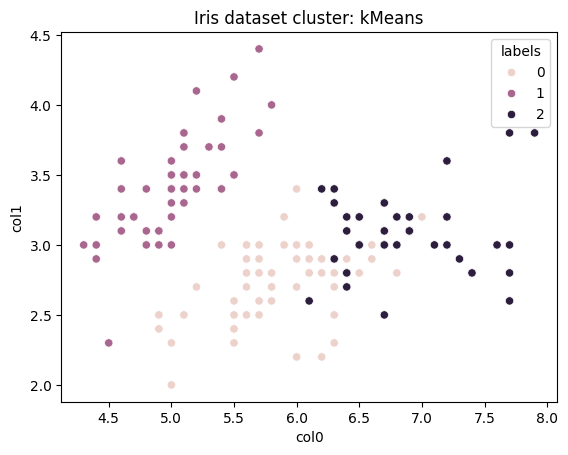

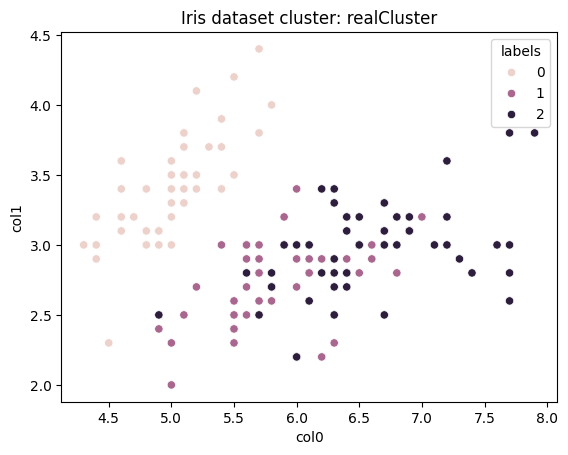

In [200]:

d_labels = apply_kMeans(X, n_clusters=3, random_state=42, n_init=10)
d_labels.update(dict(realCluster=Y))
scatter_clusters(d_labels, pd_X, x="col0", y="col1", name="Iris")

## Hierarchical clustering

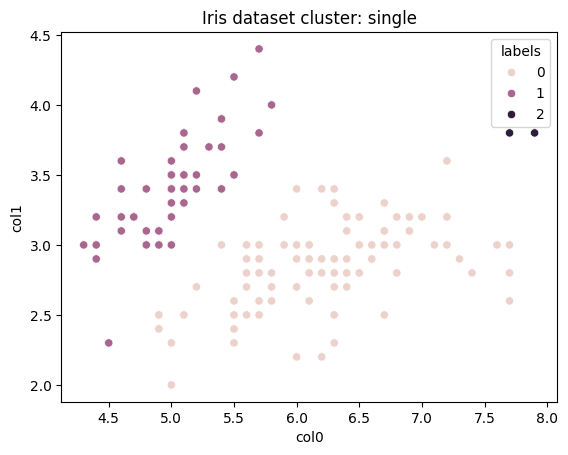

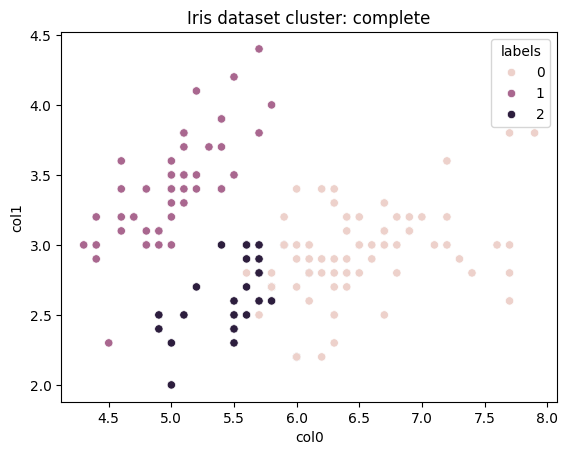

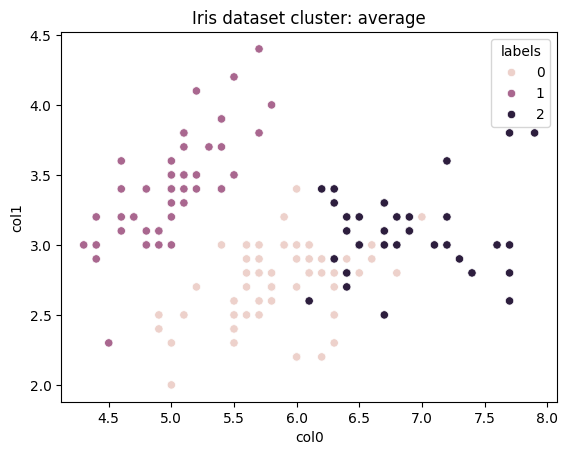

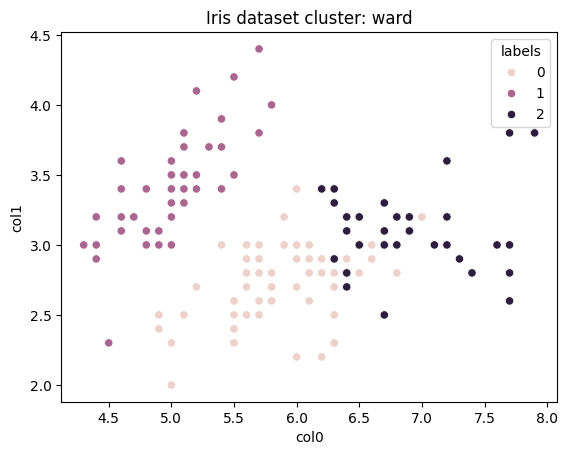

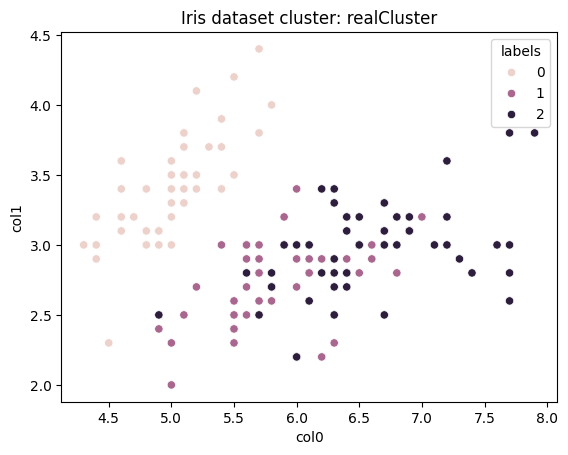

In [201]:

d_labels = apply_hierarhical_clustering(X, n_clusters=3, methods=["single", "complete", "average", "ward"])
d_labels.update(dict(realCluster=Y))
scatter_clusters(d_labels, pd_X, x="col0", y="col1", name="Iris")

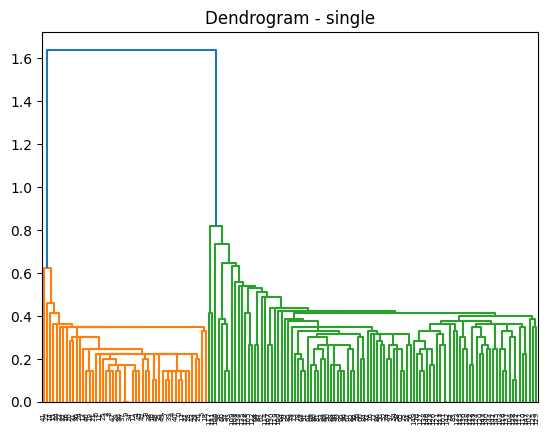

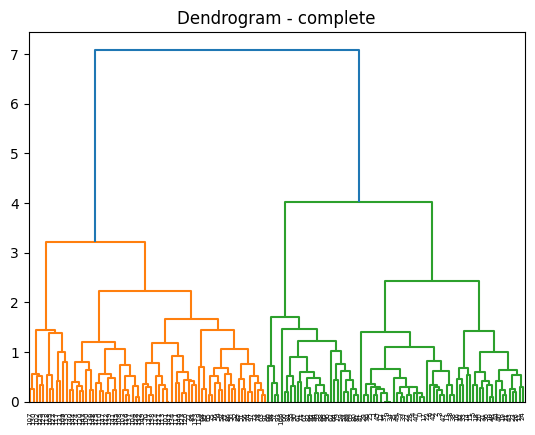

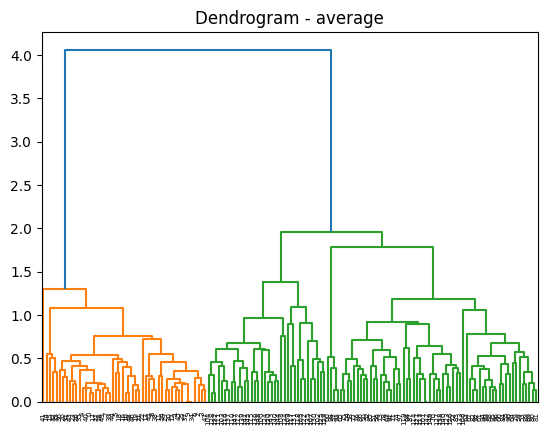

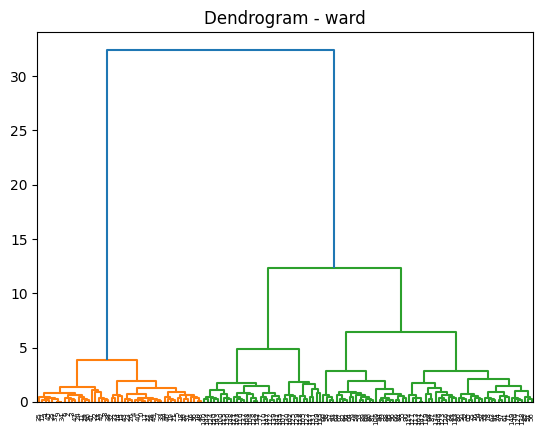

In [46]:
methods = ["single", "complete", "average", "ward"]

for method in methods:
    Z = linkage(X, method=method)
    
    plt.figure()
    dendrogram(Z)
    plt.title(f"Dendrogram - {method}")
    plt.show()

## Elbow Method kMeans

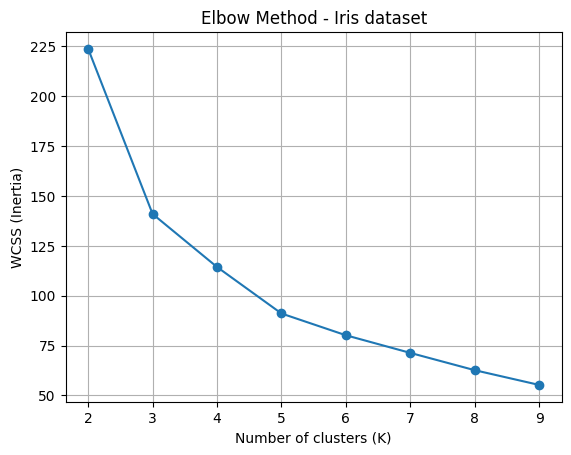

In [77]:

apply_elbow(X, name="Iris dataset")

## Silhouette Width kMeans

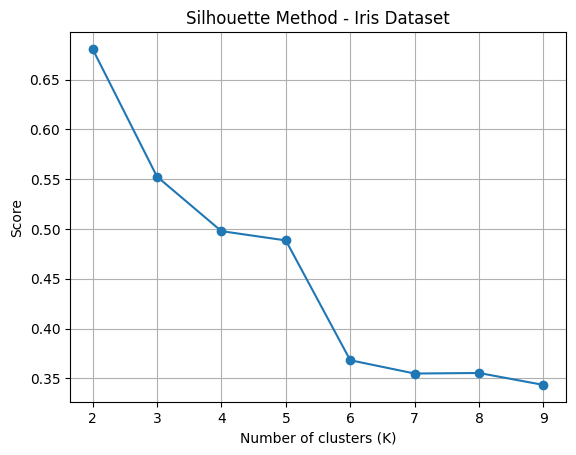

In [79]:

apply_kMeans_silhouette_score(X, name="Iris Dataset", random_state=42, n_init=20)

## Silhouette Width `ward` hierarchical clustering

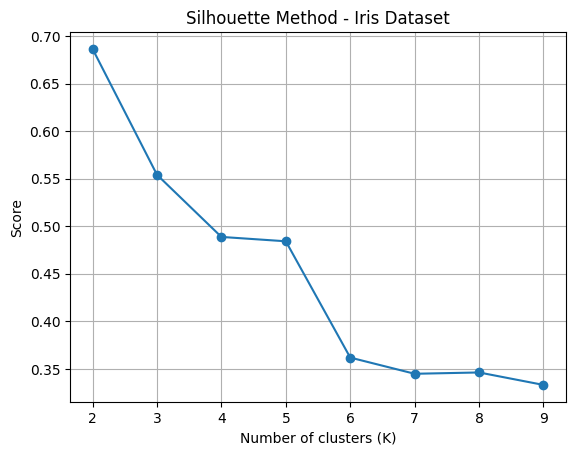

In [81]:

apply_HC_silhouette_score(X, name="Iris Dataset", random_state=42, n_init=20)

# Dataset 2d-10c

## Data aquisition

In [203]:

filename = "{}/task03/2d-10c.dat".format(DS_PATH)
pd_df = pd.read_csv(filename, sep=" ", 
                    names=["2525", "2", "labels"], 
                    header=None)
N_CLUSTERS = 10

In [204]:
pd_df.head()

,2525,2,labels
0,12.757900,-4.81962,0
1,-0.298175,-5.03868,0
2,9.155580,-3.81778,0
3,4.298230,-6.25105,0
4,8.833200,-3.48504,0


In [205]:
pd_X = pd_df.drop(columns=["labels"])
pd_Y = pd_df["labels"]
X = pd_X.copy().to_numpy()
Y = pd_Y.to_numpy()

## kMeans

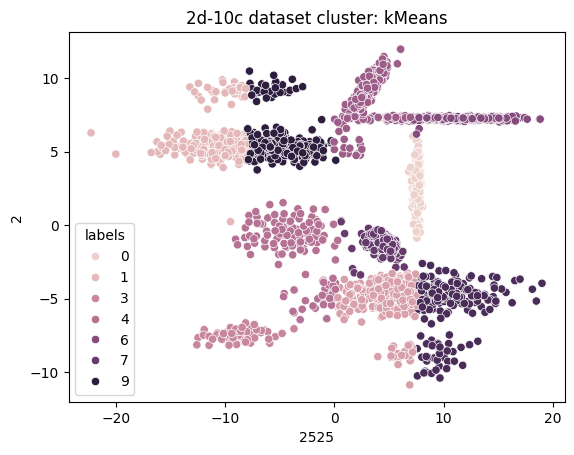

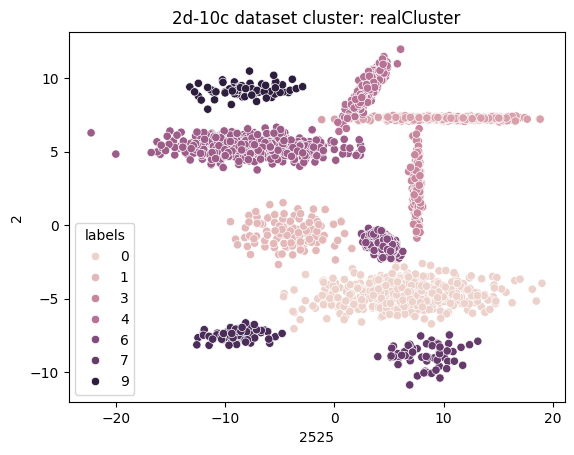

In [206]:

d_labels = apply_kMeans(X, n_clusters=N_CLUSTERS)
d_labels.update(dict(realCluster=Y))
scatter_clusters(d_labels, pd_X, x="2525", y="2", name="2d-10c")

## Hierarchical clustering

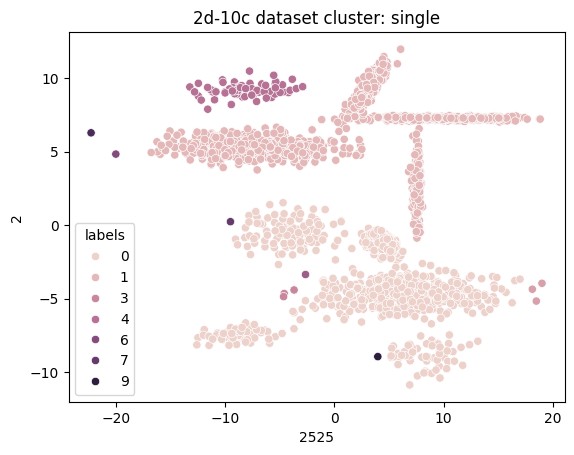

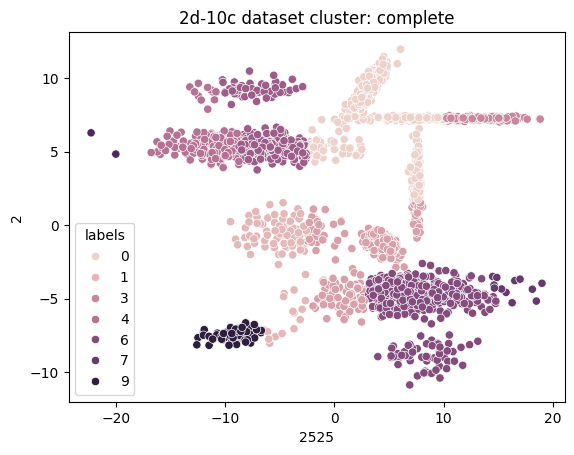

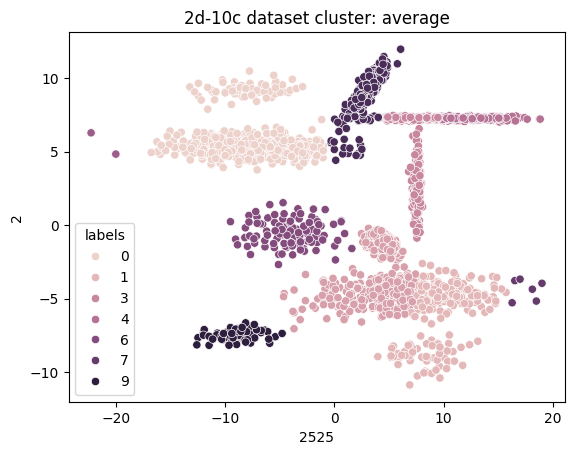

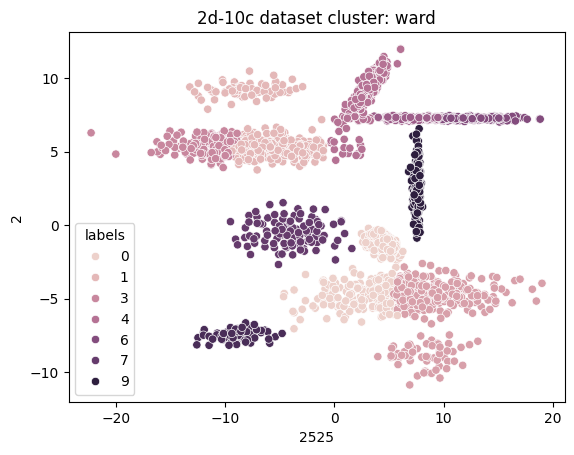

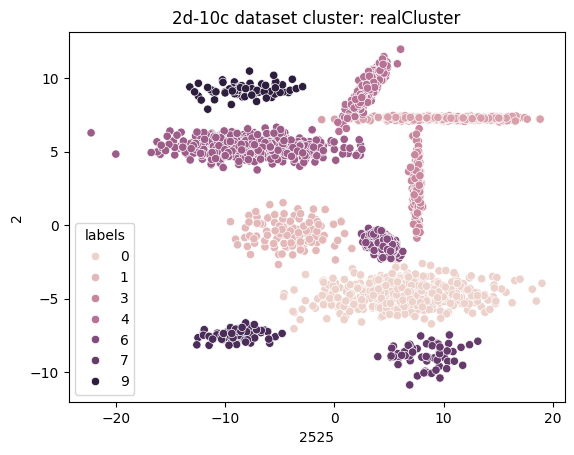

In [207]:

d_labels = apply_hierarhical_clustering(X, n_clusters=N_CLUSTERS, methods=["single", "complete", "average", "ward"])
d_labels.update(dict(realCluster=Y))
scatter_clusters(d_labels, pd_X, x="2525", y="2", name="2d-10c")

## Elbow Method kMeans

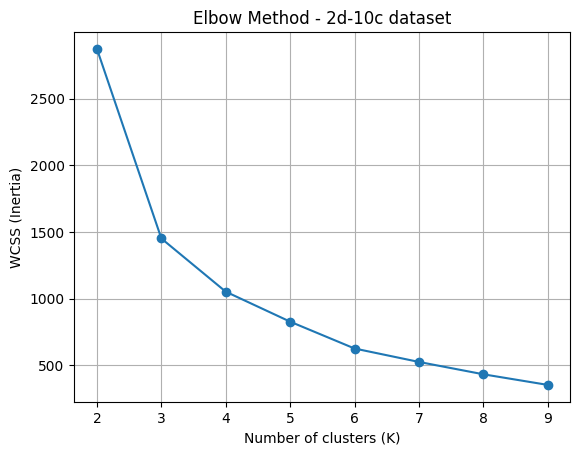

In [139]:

apply_elbow(X, name="2d-10c")

## Silhouette Width kMeans

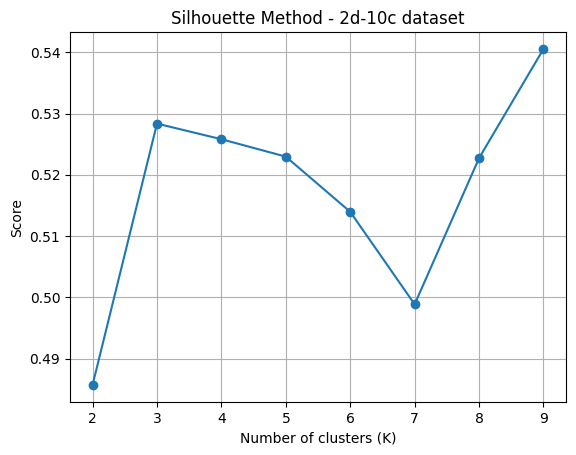

In [140]:

apply_kMeans_silhouette_score(X, name="2d-10c", random_state=42, n_init=20)

## Silhouette Width `ward` hierarchical clustering

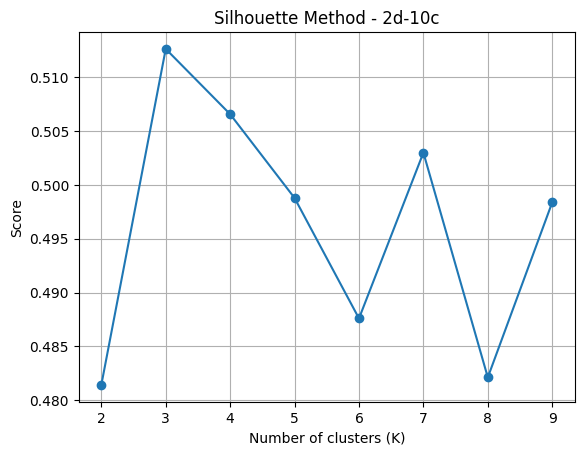

In [141]:

apply_HC_silhouette_score(X, name="2d-10c", random_state=42, n_init=20)

# Dataset heart disease

## Data aquisition

In [218]:

filename = "{}/heart_failure_prediction/heart.csv".format(DS_PATH)
pd_df = pd.read_csv(filename, 
                    #names=["col0", "col1", "col2", "col3", "labels"], 
                    #header=None
                   )
N_CLUSTERS = 2

In [219]:
pd_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [220]:
pd_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [221]:
pd_X = pd_df.drop(columns=["HeartDisease"])
pd_Y = pd_df["HeartDisease"]
X = cast_to_int(pd_df.copy(), columns=["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]).to_numpy()
Y = pd_Y.to_numpy()

{'M': 0, 'F': 1}
{'ATA': 0, 'NAP': 1, 'ASY': 2, 'TA': 3}
{'Normal': 0, 'ST': 1, 'LVH': 2}
{'N': 0, 'Y': 1}
{'Up': 0, 'Flat': 1, 'Down': 2}


## kMeans

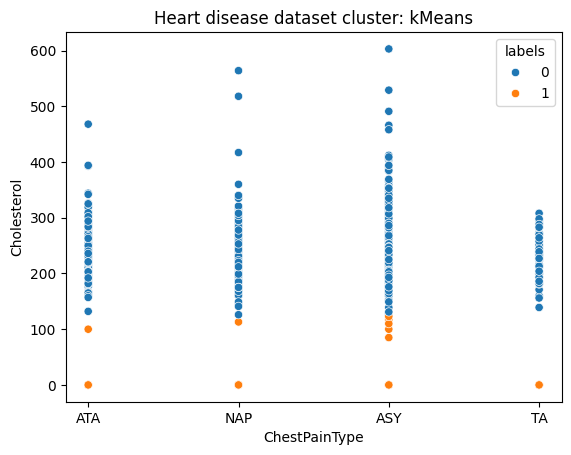

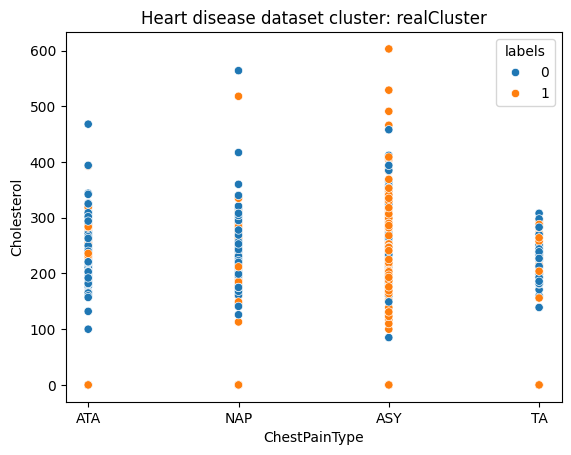

In [222]:

d_labels = apply_kMeans(X, n_clusters=N_CLUSTERS)
d_labels.update(dict(realCluster=Y))
scatter_clusters(d_labels, pd_X, x="ChestPainType", y="Cholesterol", name="Heart disease")

In [226]:

# Compute ARI
ari = adjusted_rand_score(Y, d_labels["kMeans"])

print("ARI:", ari)

ARI: 0.030336600328684057


## Hierarchical clustering

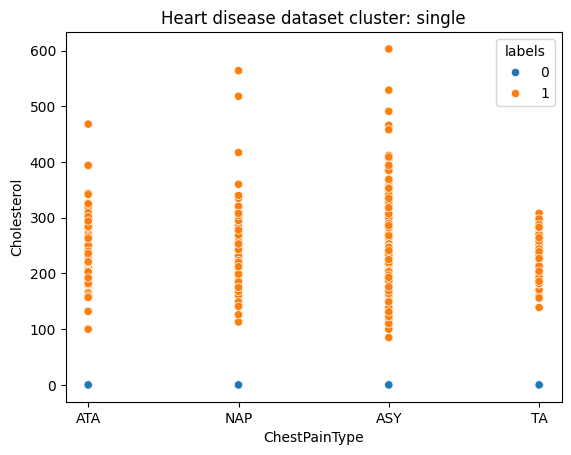

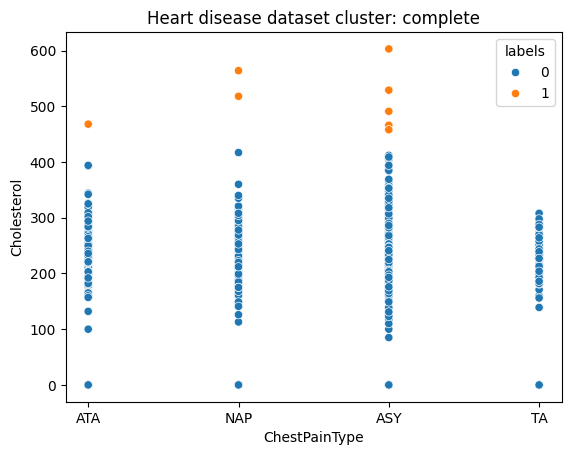

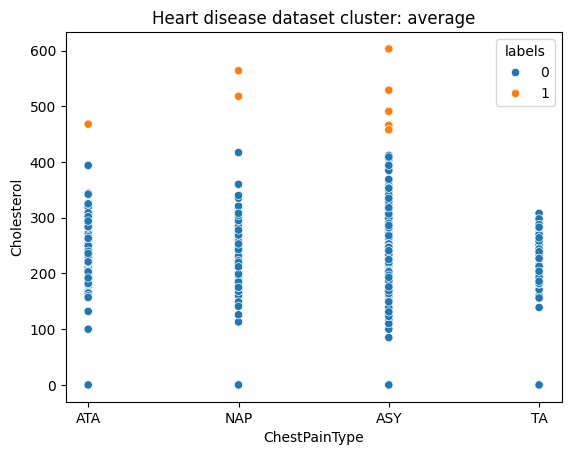

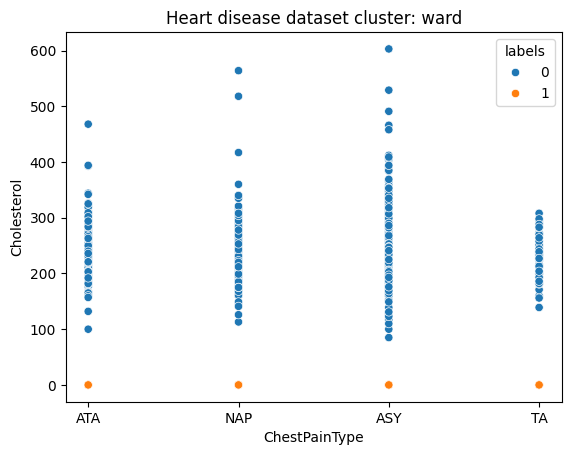

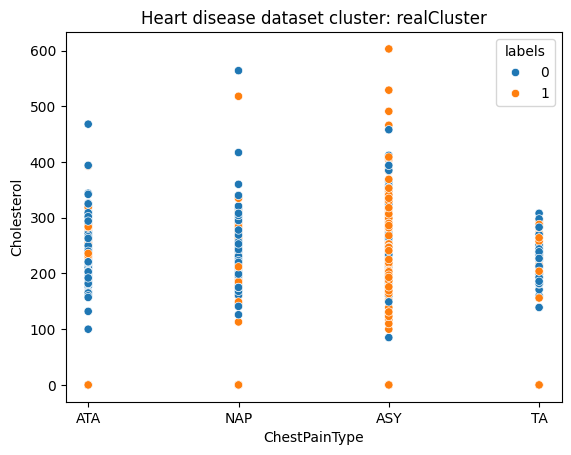

In [227]:

d_labels = apply_hierarhical_clustering(X, n_clusters=N_CLUSTERS, methods=["single", "complete", "average", "ward"])
d_labels.update(dict(realCluster=Y))
scatter_clusters(d_labels, pd_X, x="ChestPainType", y="Cholesterol", name="Heart disease")

In [229]:

for method in d_labels.keys():
    # Compute ARI
    ari = adjusted_rand_score(Y, d_labels[method])
    print("method: {}, ARI: {}".format(method, ari))

method: single, ARI: 0.027728296006753556
method: complete, ARI: -0.0005609789518399219
method: average, ARI: -0.0005609789518399219
method: ward, ARI: 0.027728296006753556
method: realCluster, ARI: 1.0


## Elbow Method kMeans

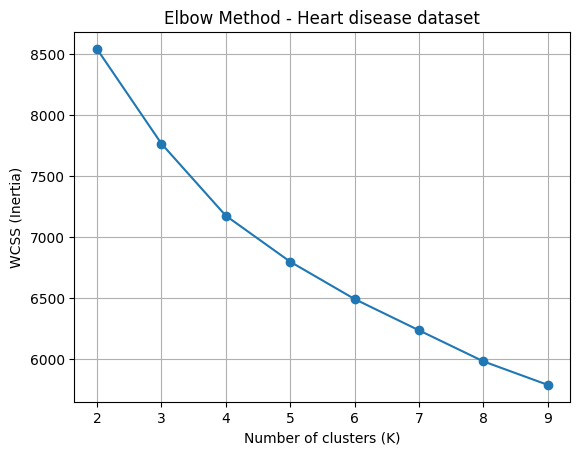

In [214]:

apply_elbow(X, name="Heart disease")

In [231]:

d_labels = apply_hierarhical_clustering(X, n_clusters=3, methods=["single", "complete", "average", "ward"])

for method in d_labels.keys():
    # Compute ARI
    ari = adjusted_rand_score(Y, d_labels[method])
    print("method: {}, ARI: {}".format(method, ari))

method: single, ARI: 0.027111497507508672
method: complete, ARI: 0.028354199638159633
method: average, ARI: 0.028354199638159633
method: ward, ARI: 0.0477305308194305


In [232]:

d_labels = apply_hierarhical_clustering(X, n_clusters=4, methods=["single", "complete", "average", "ward"])

for method in d_labels.keys():
    # Compute ARI
    ari = adjusted_rand_score(Y, d_labels[method])
    print("method: {}, ARI: {}".format(method, ari))

method: single, ARI: 0.026989743456429308
method: complete, ARI: 0.03652430573246269
method: average, ARI: 0.030182699687204436
method: ward, ARI: 0.047462628502774724


## Silhouette Width kMeans

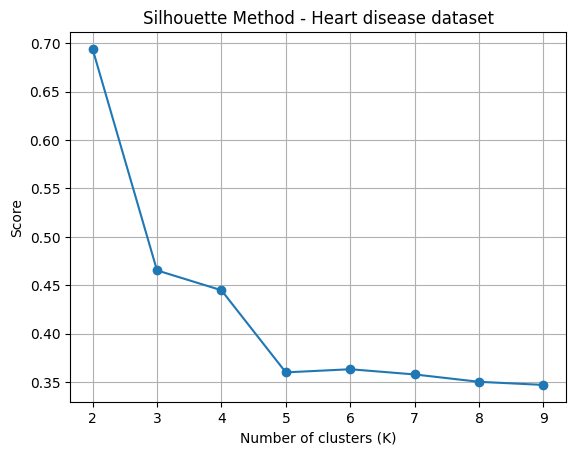

In [215]:

apply_kMeans_silhouette_score(X, name="Heart disease", random_state=42, n_init=20)

## Silhouette Width `ward` hierarchical clustering

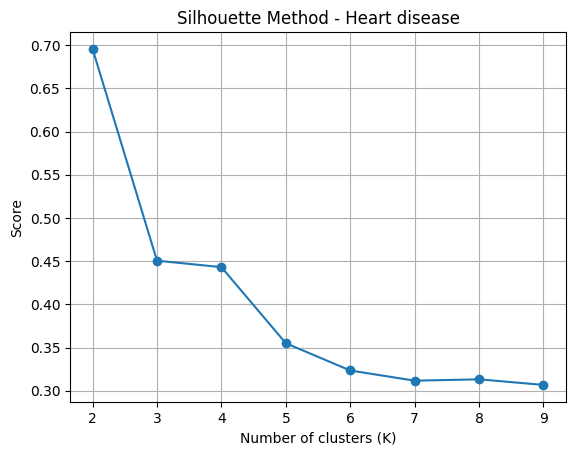

In [216]:
apply_HC_silhouette_score(X, name="Heart disease", random_state=42, n_init=20)